# RAG Eval Framework for Financial Document Q&A

A systematic evaluation framework measuring retrieval quality and answer accuracy
across a multi-document corpus (Apple + Microsoft 10-K filings).

## What This Measures
1. **Retrieval Precision**: did the right chunk get retrieved?
2. **Answer Faithfulness**: is the answer grounded in the retrieved context?
3. **Answer Correctness**: does the answer match ground truth?

## Architecture
1. **Corpus**: Apple + Microsoft 10-K filings from SEC EDGAR
2. **Test Set**: synthetic Q&A pairs generated from source chunks
3. **Pipelines**: baseline FAISS retrieval vs. FAISS + Cohere reranking
4. **Scoring**: LLM-as-judge evaluation on all three metrics

#### Installing required packages.
#### We use the same stack as RAG_10K_Assistant: OpenAI, Cohere, FAISS, and
#### sec-edgar-downloader to pull filings directly from SEC's servers.

In [14]:
!pip install -q openai cohere faiss-cpu sec-edgar-downloader beautifulsoup4

from google.colab import userdata
import os

# Pulling API keys from Colab Secrets
os.environ["SACLASS"] = userdata.get("SAClass")
os.environ["COHERE_API_KEY"] = userdata.get("COHERE_KEY")

import openai
import cohere
import faiss
import numpy as np
import json
import re
import time
from bs4 import BeautifulSoup
from pathlib import Path

# Initializing clients
openai_client = openai.OpenAI(api_key=os.environ.get("SACLASS"))
cohere_client = cohere.Client(os.environ["COHERE_API_KEY"])

print("✓ All dependencies loaded")
print("✓ API clients initialized")
print(f"SACLASS (first 5 chars): {os.environ.get('SACLASS')[:5] if os.environ.get('SACLASS') else 'None'}")

✓ All dependencies loaded
✓ API clients initialized
SACLASS (first 5 chars): sk-pr


#### Downloading Apple and Microsoft 10-K filings from SEC EDGAR.
#### We tag every chunk with its source company so we can track
#### retrieval failures by company later in the eval.

In [17]:
from sec_edgar_downloader import Downloader
from bs4 import BeautifulSoup
import os
import re

dl = Downloader("Columbia University", "ma4668@columbia.edu")

# Pulling the most recent 10-K for each company
for ticker in ["AAPL", "MSFT"]:
    dl.get("10-K", ticker, limit=1, download_details=True)
    print(f"✓ Downloaded {ticker} 10-K")

def parse_filing(ticker, download_dir="sec-edgar-filings"):
    """Parse all HTML files for a given ticker into a single text string."""
    ticker_dir = os.path.join(download_dir, ticker, "10-K")
    full_text = ""
    for root, dirs, files in os.walk(ticker_dir):
        for file in files:
            if file.endswith(".html"):
                with open(os.path.join(root, file), "r", encoding="utf-8") as f:
                    soup = BeautifulSoup(f.read(), "html.parser")
                    full_text += soup.get_text() + " "
    return full_text.strip()

def chunk_text(text, chunk_size=500):
    """Split text into chunks, ensuring no chunk exceeds chunk_size, even if it means splitting sentences."""
    chunks = []
    current_chunk = ""
    # Spliting text by common delimiters that might imply sentence or logical breaks
    # This is a heuristic and might still produce long segments if delimiters are scarce
    segments = re.split(r'(?<=[.!?])\s+|\n\n+|(?<=;)\s+', text) # Splitting by sentence end punctuation + space, or double newline or semicolon

    for segment in segments:
        if not segment.strip(): # Skipping empty segments
            continue

        # If adding the segment makes current_chunk too long
        if len(current_chunk) + len(segment) + 1 > chunk_size and current_chunk: # +1 for space
            chunks.append(current_chunk.strip())
            current_chunk = ""

        # If the segment itself is too long, split it further
        while len(segment) > chunk_size:
            chunks.append(segment[:chunk_size].strip())
            segment = segment[chunk_size:]

        # Adding remaining part of the segment
        if segment.strip():
            current_chunk += segment.strip() + " "

    if current_chunk:
        chunks.append(current_chunk.strip())
    return chunks

# Building the unified corpus — each entry carries text + source company
corpus = []
for ticker in ["AAPL", "MSFT"]:
    text = parse_filing(ticker)
    chunks = chunk_text(text)
    for chunk in chunks:
        corpus.append({"text": chunk, "source": ticker})
    print(f"✓ {ticker}: {len(chunks)} chunks")

print(f"\nTotal corpus size: {len(corpus)} chunks")

✓ Downloaded AAPL 10-K
✓ Downloaded MSFT 10-K
✓ AAPL: 545 chunks
✓ MSFT: 865 chunks

Total corpus size: 1410 chunks


#### Building a FAISS index over the unified corpus.
#### We embed every chunk once here and store the embeddings so we
#### don't have to re-call the OpenAI API every time we run a query.


In [18]:
# Ensure the API key is retrieved from the environment variable
# This assumes the SACLASS environment variable has been set in a previous cell.
openai_api_key = os.environ.get("SACLASS")
client = OpenAI(api_key=openai_api_key)

def get_embedding(text, model="text-embedding-3-small"):
    """Get a single embedding from OpenAI — same as RAG_10K_Assistant."""
    response = client.embeddings.create(input=text, model=model)
    return response.data[0].embedding

# Embedding every chunk in the corpus
# This will take ~1-2 minutes for a combined corpus of 2 filings
print("Embedding corpus chunks...")
embeddings = []
for i, item in enumerate(corpus):
    embedding = get_embedding(item["text"])
    embeddings.append(embedding)
    if (i + 1) % 100 == 0:
        print(f"  {i + 1}/{len(corpus)} chunks embedded")

embeddings_array = np.array(embeddings).astype("float32")

# Building the FAISS index — IndexFlatL2 does exact L2 search,
# same as your original pipeline
dimension = embeddings_array.shape[1]  # 1536 for text-embedding-3-small
index = faiss.IndexFlatL2(dimension)
index.add(embeddings_array)

print(f"\n✓ FAISS index built")
print(f"  {index.ntotal} vectors indexed at {dimension} dimensions")

Embedding corpus chunks...
  100/1410 chunks embedded
  200/1410 chunks embedded
  300/1410 chunks embedded
  400/1410 chunks embedded
  500/1410 chunks embedded
  600/1410 chunks embedded
  700/1410 chunks embedded
  800/1410 chunks embedded
  900/1410 chunks embedded
  1000/1410 chunks embedded
  1100/1410 chunks embedded
  1200/1410 chunks embedded
  1300/1410 chunks embedded
  1400/1410 chunks embedded

✓ FAISS index built
  1410 vectors indexed at 1536 dimensions


#### Generating a synthetic test set by asking GPT-4o-mini to produce
#### question-answer pairs directly from sampled corpus chunks.
#### The chunk each Q&A pair came from becomes the ground truth chunk
#### for retrieval evaluation, if the pipeline retrieves it, that's a hit.

In [19]:
import json
import random

random.seed(42)  # Fixing seed so the test set is reproducible across runs

def generate_qa_from_chunk(chunk_text, source):
    """Ask GPT-4o-mini to generate one question-answer pair from a chunk.
    We specify JSON output so we can parse it reliably."""

    prompt = f"""You are building an evaluation dataset for a RAG system.

Given the following excerpt from {source}'s 10-K SEC filing, generate exactly one
question-answer pair that:
- Can only be answered using this excerpt (not general knowledge)
- Has a specific, verifiable answer (not vague or opinion-based)
- Would be a realistic question a financial analyst might ask

Respond with valid JSON only, no other text:
{{"question": "...", "answer": "..."}}

Excerpt:
{chunk_text}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,  # Low temperature — we want factual not creative
        max_tokens=300
    )

    raw = response.choices[0].message.content.strip()

    # Stripping markdown code fences if GPT wraps output in ```json ... ```
    raw = raw.replace("```json", "").replace("```", "").strip()

    return json.loads(raw)

# Sampling chunks evenly across both companies so the test set
# isn't accidentally skewed toward one filing
aapl_chunks = [item for item in corpus if item["source"] == "AAPL"]
msft_chunks = [item for item in corpus if item["source"] == "MSFT"]

sample_aapl = random.sample(aapl_chunks, 10)
sample_msft = random.sample(msft_chunks, 10)
sampled_chunks = sample_aapl + sample_msft  # 20 questions total

# Generating Q&A pairs and attaching the source chunk as ground truth
print("Generating test set...")
test_set = []

for i, item in enumerate(sampled_chunks):
    try:
        qa = generate_qa_from_chunk(item["text"], item["source"])
        test_set.append({
            "question": qa["question"],
            "ground_truth_answer": qa["answer"],
            "ground_truth_chunk": item["text"],  # The chunk this Q&A came from
            "source": item["source"]
        })
        print(f"  ✓ {i+1}/20 — {item['source']}: {qa['question'][:60]}...")
    except Exception as e:
        print(f"  ✗ {i+1}/20 — skipped ({e})")

# Saving to disk so we don't regenerate on every run
with open("test_set.json", "w") as f:
    json.dump(test_set, f, indent=2)

print(f"\n✓ Test set saved: {len(test_set)} questions across AAPL and MSFT")

Generating test set...
  ✓ 1/20 — AAPL: How have major public health issues like the COVID-19 pandem...
  ✓ 2/20 — AAPL: What is the country associated with the filing date of 2023-...
  ✓ 3/20 — AAPL: What date did the Company file a statement of compliance wit...
  ✓ 4/20 — AAPL: What financial instruments does the Company use to hedge aga...
  ✓ 5/20 — AAPL: What company was found to have violated U.S. antitrust laws ...
  ✓ 6/20 — AAPL: What factors may limit the Company's ability to obtain suffi...
  ✓ 7/20 — AAPL: How can trade and other international disputes affect the Co...
  ✓ 8/20 — AAPL: What are the potential impacts of the summarized risk factor...
  ✓ 9/20 — AAPL: What were the noncash activities involving right-of-use asse...
  ✓ 10/20 — AAPL: What type of filer is AAPL classified as in its 10-K SEC fil...
  ✓ 11/20 — MSFT: What is the expiration date for the Performance Shares Membe...
  ✓ 12/20 — MSFT: What types of applications is Microsoft investing in to tran...
  

#### Running every test question through both pipelines and recording
#### what each one retrieved and generated.
#### We store full results so Section 6 can score them without re-querying.

In [21]:
import cohere
co = cohere.Client(os.environ["COHERE_API_KEY"])

def search(query, index, corpus, k=10):
    """Retrieve top-k chunks from FAISS for a given query."""
    query_embedding = np.array([get_embedding(query)]).astype("float32")
    distances, indices = index.search(query_embedding, k)
    return [{"chunk": corpus[idx]["text"], "source": corpus[idx]["source"], "distance": float(distances[0][i])}
            for i, idx in enumerate(indices[0])]

def rerank(query, candidate_chunks, top_n=3):
    """Rerank retrieved chunks using Cohere cross-encoder, return top_n."""
    results = co.rerank(
        query=query,
        documents=candidate_chunks,
        top_n=top_n,
        model="rerank-english-v3.0"
    )
    return [candidate_chunks[r.index] for r in results.results]

def generate_answer(query, context_chunks):
    """Generate an answer from GPT-4o-mini given a query and retrieved chunks."""
    context = "\n\n".join([f"Context {i+1}: {chunk}" for i, chunk in enumerate(context_chunks)])
    prompt = f"""Based on the following context, answer the question.
Only use information from the provided context. If the answer isn't in the context, say so.

{context}

Question: {query}
Answer:"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You are a financial analyst assistant. Answer only from the provided context."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,
        max_tokens=300
    )
    return response.choices[0].message.content.strip()

# Loading test set from disk — using the saved version so results
# are comparable across runs
with open("test_set.json", "r") as f:
    test_set = json.load(f)

print(f"Running {len(test_set)} questions through both pipelines...\n")
results = []

for i, item in enumerate(test_set):
    query = item["question"]

    # ── Baseline: FAISS top-3 → generate ──────────────────────────────
    baseline_retrieved = search(query, index, corpus, k=3)
    baseline_chunks = [r["chunk"] for r in baseline_retrieved]
    baseline_answer = generate_answer(query, baseline_chunks)

    # ── Reranked: FAISS top-10 → Cohere rerank to top-3 → generate ────
    reranked_retrieved = search(query, index, corpus, k=10)
    reranked_candidates = [r["chunk"] for r in reranked_retrieved]
    reranked_chunks = rerank(query, reranked_candidates, top_n=3)
    reranked_answer = generate_answer(query, reranked_chunks)

    # Add a delay to respect Cohere's rate limit
    time.sleep(6)

    results.append({
        "question": query,
        "source": item["source"],
        "ground_truth_answer": item["ground_truth_answer"],
        "ground_truth_chunk": item["ground_truth_chunk"],
        "baseline_chunks": baseline_chunks,
        "baseline_answer": baseline_answer,
        "reranked_chunks": reranked_chunks,
        "reranked_answer": reranked_answer
    })

    print(f"  ✓ {i+1}/{len(test_set)} — {item['source']}: {query[:60]}...")

# Saving results to disk before scoring — if scoring fails we
# don't have to re-run the expensive pipeline step
with open("pipeline_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"\n✓ Pipeline results saved: {len(results)} questions")

Running 20 questions through both pipelines...

  ✓ 1/20 — AAPL: How have major public health issues like the COVID-19 pandem...
  ✓ 2/20 — AAPL: What is the country associated with the filing date of 2023-...
  ✓ 3/20 — AAPL: What date did the Company file a statement of compliance wit...
  ✓ 4/20 — AAPL: What financial instruments does the Company use to hedge aga...
  ✓ 5/20 — AAPL: What company was found to have violated U.S. antitrust laws ...
  ✓ 6/20 — AAPL: What factors may limit the Company's ability to obtain suffi...
  ✓ 7/20 — AAPL: How can trade and other international disputes affect the Co...
  ✓ 8/20 — AAPL: What are the potential impacts of the summarized risk factor...
  ✓ 9/20 — AAPL: What were the noncash activities involving right-of-use asse...
  ✓ 10/20 — AAPL: What type of filer is AAPL classified as in its 10-K SEC fil...
  ✓ 11/20 — MSFT: What is the expiration date for the Performance Shares Membe...
  ✓ 12/20 — MSFT: What types of applications is Microsoft i

#### Scoring every result across three metrics using GPT-4o-mini as judge.
#### LLM-as-judge is standard practice when answers are free-form text,
#### you can't do exact string matching on financial answers.

In [22]:
def score_retrieval_precision(ground_truth_chunk, retrieved_chunks):
    """Check if the ground truth chunk appears in what was retrieved.
    This is a direct string match — no LLM needed, no ambiguity."""
    return int(any(ground_truth_chunk.strip() in chunk.strip()
                   for chunk in retrieved_chunks))

def score_faithfulness(answer, retrieved_chunks, client):
    """Score whether the answer is grounded in the retrieved context.
    Catches hallucination — model making claims not in the retrieved text."""
    context = "\n\n".join([f"Context {i+1}: {chunk}"
                           for i, chunk in enumerate(retrieved_chunks)])

    prompt = f"""You are evaluating whether an AI-generated answer is faithful to its source context.

Context that was retrieved:
{context}

Generated answer:
{answer}

Score the answer on a scale of 0.0 to 1.0:
- 1.0: Every claim in the answer is directly supported by the context
- 0.5: Answer is mostly supported but contains minor unsupported claims
- 0.0: Answer contains significant claims not found in the context

Respond with valid JSON only:
{{"score": <number>, "reason": "<one sentence explanation>"}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,  # Zero temperature — scoring should be deterministic
        max_tokens=150
    )
    raw = response.choices[0].message.content.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()
    parsed = json.loads(raw)
    return parsed["score"], parsed["reason"]

def score_correctness(generated_answer, ground_truth_answer, client):
    """Score whether the generated answer matches the ground truth.
    This is the end-to-end quality metric — did the full pipeline get it right."""

    prompt = f"""You are evaluating whether an AI-generated answer correctly answers a question.

Ground truth answer:
{ground_truth_answer}

Generated answer:
{generated_answer}

Score the generated answer on a scale of 0.0 to 1.0:
- 1.0: Correct and complete — matches the ground truth
- 0.5: Partially correct — captures some but not all key information
- 0.0: Incorrect or missing the point entirely

Respond with valid JSON only:
{{"score": <number>, "reason": "<one sentence explanation>"}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=150
    )
    raw = response.choices[0].message.content.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()
    parsed = json.loads(raw)
    return parsed["score"], parsed["reason"]

# Loading saved pipeline results — scoring separately from retrieval
# so we don't repeat expensive API calls if this cell needs a rerun
with open("pipeline_results.json", "r") as f:
    results = json.load(f)

print(f"Scoring {len(results)} results...\n")
scored_results = []

for i, item in enumerate(results):

    # ── Retrieval Precision — did the right chunk get retrieved? ───────
    baseline_precision = score_retrieval_precision(
        item["ground_truth_chunk"], item["baseline_chunks"])
    reranked_precision = score_retrieval_precision(
        item["ground_truth_chunk"], item["reranked_chunks"])

    # ── Faithfulness — is the answer grounded in retrieved context? ────
    baseline_faith, baseline_faith_reason = score_faithfulness(
        item["baseline_answer"], item["baseline_chunks"], client)
    reranked_faith, reranked_faith_reason = score_faithfulness(
        item["reranked_answer"], item["reranked_chunks"], client)

    # ── Correctness — does the answer match ground truth? ──────────────
    baseline_correct, baseline_correct_reason = score_correctness(
        item["baseline_answer"], item["ground_truth_answer"], client)
    reranked_correct, reranked_correct_reason = score_correctness(
        item["reranked_answer"], item["ground_truth_answer"], client)

    scored_results.append({
        **item,  # Carrying forward all pipeline results
        "baseline_precision": baseline_precision,
        "reranked_precision": reranked_precision,
        "baseline_faithfulness": baseline_faith,
        "baseline_faithfulness_reason": baseline_faith_reason,
        "reranked_faithfulness": reranked_faith,
        "reranked_faithfulness_reason": reranked_faith_reason,
        "baseline_correctness": baseline_correct,
        "baseline_correctness_reason": baseline_correct_reason,
        "reranked_correctness": reranked_correct,
        "reranked_correctness_reason": reranked_correct_reason,
    })

    print(f"  ✓ {i+1}/{len(results)} — {item['source']}: precision {baseline_precision}→{reranked_precision} | correctness {baseline_correct:.1f}→{reranked_correct:.1f}")

# Saving scored results before visualization
with open("scored_results.json", "w") as f:
    json.dump(scored_results, f, indent=2)

print(f"\n✓ Scoring complete. Results saved to scored_results.json")

Scoring 20 results...

  ✓ 1/20 — AAPL: precision 1→1 | correctness 0.5→0.5
  ✓ 2/20 — AAPL: precision 1→1 | correctness 1.0→1.0
  ✓ 3/20 — AAPL: precision 1→1 | correctness 1.0→1.0
  ✓ 4/20 — AAPL: precision 1→1 | correctness 1.0→0.5
  ✓ 5/20 — AAPL: precision 1→1 | correctness 0.0→0.0
  ✓ 6/20 — AAPL: precision 1→1 | correctness 0.5→1.0
  ✓ 7/20 — AAPL: precision 1→1 | correctness 0.5→1.0
  ✓ 8/20 — AAPL: precision 1→1 | correctness 1.0→1.0
  ✓ 9/20 — AAPL: precision 1→1 | correctness 1.0→1.0
  ✓ 10/20 — AAPL: precision 0→0 | correctness 0.0→0.0
  ✓ 11/20 — MSFT: precision 0→1 | correctness 0.0→0.0
  ✓ 12/20 — MSFT: precision 1→1 | correctness 0.5→0.5
  ✓ 13/20 — MSFT: precision 1→1 | correctness 0.5→0.5
  ✓ 14/20 — MSFT: precision 0→0 | correctness 0.0→0.0
  ✓ 15/20 — MSFT: precision 1→1 | correctness 0.5→0.5
  ✓ 16/20 — MSFT: precision 1→1 | correctness 0.5→0.5
  ✓ 17/20 — MSFT: precision 0→1 | correctness 1.0→1.0
  ✓ 18/20 — MSFT: precision 1→1 | correctness 1.0→1.0
  ✓ 19/20 — MS

#### Summarizing eval results into aggregate metrics and visualizing
#### where each pipeline wins, loses, and why.

METRIC                         BASELINE   RERANKED
Retrieval Precision (overall)       0.80       0.90
Answer Faithfulness (overall)       0.90       0.93
Answer Correctness (overall)       0.62       0.65
------------------------------------------------------------
Retrieval Precision (AAPL)         0.90       0.90
Retrieval Precision (MSFT)         0.70       0.90
Answer Correctness (AAPL)          0.65       0.70
Answer Correctness (MSFT)          0.60       0.60


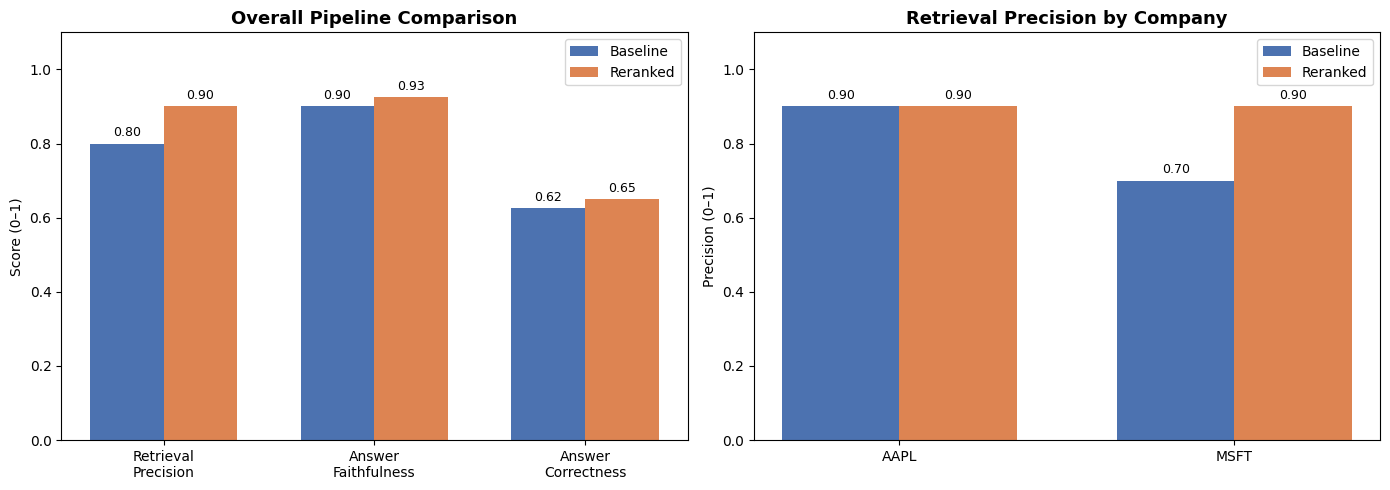

✓ Chart saved as eval_results.png

── Failure Cases (correctness < 0.5 on both pipelines) ──────────────

[AAPL] What company was found to have violated U.S. antitrust laws on August 5, 2024?
  Ground truth:      Google LLC
  Baseline answer:   Google was found to have violated U.S. antitrust laws on August 5, 2024....
  Reranked answer:   Google was found to have violated U.S. antitrust laws on August 5, 2024....
  Baseline reason:   The generated answer does not mention 'Google LLC' and instead focuses on a specific event related to antitrust laws, missing the core identification of the entity.
  Reranked reason:   The generated answer does not provide the correct name of the company, which is the key information in the question.

[AAPL] What type of filer is AAPL classified as in its 10-K SEC filing?
  Ground truth:      Large accelerated filer
  Baseline answer:   The context does not provide information regarding the classification of AAPL as a filer in its 10-K SEC filing....
  R

In [23]:
import matplotlib.pyplot as plt
import numpy as np

with open("scored_results.json", "r") as f:
    scored_results = json.load(f)

# ── Aggregate Metrics ──────────────────────────────────────────────────────

def aggregate(results, company=None):
    """Compute mean scores across all results, optionally filtered by company."""
    subset = results if company is None else [r for r in results if r["source"] == company]
    n = len(subset)
    return {
        "n": n,
        "retrieval_precision": sum(r["baseline_precision"] for r in subset) / n,
        "reranked_precision": sum(r["reranked_precision"] for r in subset) / n,
        "baseline_faithfulness": sum(r["baseline_faithfulness"] for r in subset) / n,
        "reranked_faithfulness": sum(r["reranked_faithfulness"] for r in subset) / n,
        "baseline_correctness": sum(r["baseline_correctness"] for r in subset) / n,
        "reranked_correctness": sum(r["reranked_correctness"] for r in subset) / n,
    }

overall = aggregate(scored_results)
aapl    = aggregate(scored_results, "AAPL")
msft    = aggregate(scored_results, "MSFT")

print("=" * 60)
print(f"{'METRIC':<28} {'BASELINE':>10} {'RERANKED':>10}")
print("=" * 60)
print(f"{'Retrieval Precision (overall)':<28} {overall['retrieval_precision']:>10.2f} {overall['reranked_precision']:>10.2f}")
print(f"{'Answer Faithfulness (overall)':<28} {overall['baseline_faithfulness']:>10.2f} {overall['reranked_faithfulness']:>10.2f}")
print(f"{'Answer Correctness (overall)':<28} {overall['baseline_correctness']:>10.2f} {overall['reranked_correctness']:>10.2f}")
print("-" * 60)
print(f"{'Retrieval Precision (AAPL)':<28} {aapl['retrieval_precision']:>10.2f} {aapl['reranked_precision']:>10.2f}")
print(f"{'Retrieval Precision (MSFT)':<28} {msft['retrieval_precision']:>10.2f} {msft['reranked_precision']:>10.2f}")
print(f"{'Answer Correctness (AAPL)':<28} {aapl['baseline_correctness']:>10.2f} {aapl['reranked_correctness']:>10.2f}")
print(f"{'Answer Correctness (MSFT)':<28} {msft['baseline_correctness']:>10.2f} {msft['reranked_correctness']:>10.2f}")
print("=" * 60)

# ── Visualization ──────────────────────────────────────────────────────────

metrics = ["Retrieval\nPrecision", "Answer\nFaithfulness", "Answer\nCorrectness"]
baseline_scores = [overall["retrieval_precision"], overall["baseline_faithfulness"], overall["baseline_correctness"]]
reranked_scores = [overall["reranked_precision"],  overall["reranked_faithfulness"],  overall["reranked_correctness"]]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Overall baseline vs reranked across all three metrics
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, baseline_scores, width, label="Baseline", color="#4C72B0")
bars2 = ax1.bar(x + width/2, reranked_scores, width, label="Reranked", color="#DD8452")
ax1.set_title("Overall Pipeline Comparison", fontsize=13, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.set_ylabel("Score (0–1)")
ax1.legend()
ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)
ax1.bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)

# Chart 2 — Retrieval precision broken down by company
# This is where multi-document corpus pays off — we can see if one
# company's chunks are systematically harder to retrieve
companies = ["AAPL", "MSFT"]
baseline_prec = [aapl["retrieval_precision"], msft["retrieval_precision"]]
reranked_prec = [aapl["reranked_precision"],  msft["reranked_precision"]]

x2 = np.arange(len(companies))
ax2 = axes[1]
bars3 = ax2.bar(x2 - width/2, baseline_prec, width, label="Baseline", color="#4C72B0")
bars4 = ax2.bar(x2 + width/2, reranked_prec, width, label="Reranked", color="#DD8452")
ax2.set_title("Retrieval Precision by Company", fontsize=13, fontweight="bold")
ax2.set_xticks(x2)
ax2.set_xticklabels(companies)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel("Precision (0–1)")
ax2.legend()
ax2.bar_label(bars3, fmt="%.2f", padding=3, fontsize=9)
ax2.bar_label(bars4, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("eval_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved as eval_results.png")

# ── Failure Analysis ───────────────────────────────────────────────────────
# Surfacing the specific questions where both pipelines failed —
# these are the most useful signal for what to fix next

print("\n── Failure Cases (correctness < 0.5 on both pipelines) ──────────────\n")
failures = [r for r in scored_results
            if r["baseline_correctness"] < 0.5 and r["reranked_correctness"] < 0.5]

if not failures:
    print("No complete failures — both pipelines answered every question reasonably.")
else:
    for r in failures:
        print(f"[{r['source']}] {r['question']}")
        print(f"  Ground truth:      {r['ground_truth_answer']}")
        print(f"  Baseline answer:   {r['baseline_answer'][:120]}...")
        print(f"  Reranked answer:   {r['reranked_answer'][:120]}...")
        print(f"  Baseline reason:   {r['baseline_correctness_reason']}")
        print(f"  Reranked reason:   {r['reranked_correctness_reason']}")
        print()

print(f"Total failures: {len(failures)}/{len(scored_results)}")

## What I'd improve next

* **Semantic chunking**: detect topic boundaries instead of splitting by character count
* **Chunk overlap**: 1-2 sentence overlap at boundaries to avoid splitting key facts across chunks
* **Metadata filtering**: tag chunks by filing section (Item 7, Item 8) and filter at query time
* **Larger test set**: 20 questions is enough to show the framework works; 100+ would give statistically reliable scores
* **Human-labeled ground truth**: synthetic Q&A pairs generated from chunks are a good start but a human-reviewed test set would be more rigorous
* **Cross-year corpus**: add 2022 and 2023 filings to surface temporal retrieval failures (e.g. "revenue in 2023" pulling the wrong year)